In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load data from sql loss_profit.db

In [2]:
# Load database .db from pipelines/data_engineer/database/loss_profit.db
from sqlalchemy import create_engine, text
from pathlib import Path

CURR_DIR = Path.cwd()
ROOT_DIR = CURR_DIR.parent.parent
DB_PATH = ROOT_DIR / 'data_engineer' / 'database' / 'loss_profit_renew.db'

# Load data base .db and check tables
engine = create_engine(f'sqlite:///{DB_PATH}')
with engine.connect() as connection:
    result = connection.execute(text("SELECT name FROM sqlite_master WHERE type='table';"))
    tables = result.fetchall()
    print("Tables in the database:")
    for table in tables:
        print(table[0])

if tables:
    for table_name in tables:
        with engine.connect() as connection:
            query = text(f"SELECT * FROM {table_name[0]}")
            df = pd.read_sql(query, connection)
            print(f"\nData from table '{table_name[0]}':")
            print(f"Database: {df.head()}")
else:
    print("No tables found in the database.")

Tables in the database:
loss_profit

Data from table 'loss_profit':
Database:        item_id  purchase_count  view_count   price  stocks     sales  \
0  item_000001              56          91  365256     119  20454336   
1  item_000002              83         212  249729     104  20727507   
2  item_000003             176         166  276724      97  48703424   
3  item_000004              63         132  314195     123  19794285   
4  item_000005               3         506  213034     162    639102   

   stock_value_retail profit_status  conversion_rate  
0            43465464        profit        61.538462  
1            25971816        profit        39.150943  
2            26842228        profit       106.024096  
3            38645985        profit        47.727273  
4            34511508        profit         0.592885  


## Database as df -> Transformed database by data_engineer dir

### - **Added new column on total_revenue, stock_value, profit_status**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   item_id             300000 non-null  object 
 1   purchase_count      300000 non-null  int64  
 2   view_count          300000 non-null  int64  
 3   price               300000 non-null  int64  
 4   stocks              300000 non-null  int64  
 5   sales               300000 non-null  int64  
 6   stock_value_retail  300000 non-null  int64  
 7   profit_status       300000 non-null  object 
 8   conversion_rate     300000 non-null  float64
dtypes: float64(1), int64(6), object(2)
memory usage: 20.6+ MB


In [4]:
df.describe()

,purchase_count,view_count,price,stocks,sales,stock_value_retail,conversion_rate
count,300000.000000,300000.000000,300000.000000,300000.000000,3.000000e+05,3.000000e+05,300000.000000
mean,29.505340,798.099583,275214.493157,100.166573,8.118207e+06,2.756189e+07,25.166193
std,29.936504,799.071223,85160.601177,58.032946,8.973939e+06,1.877912e+07,197.720139
min,0.000000,0.000000,53402.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,8.000000,228.000000,224457.750000,50.000000,2.014958e+06,1.200870e+07,1.164725
50%,20.000000,552.000000,288549.000000,100.000000,5.194244e+06,2.433093e+07,3.631961
75%,41.000000,1107.000000,336060.750000,150.000000,1.104536e+07,4.128084e+07,11.067848
max,348.000000,10367.000000,572572.000000,200.000000,1.443639e+08,1.013616e+08,22200.000000


## Feature engineering

In [5]:
# Fix item_id at the source (run before everything)
NUM_ITEMS = 882
item_pool = [f"item_{str(i).zfill(6)}" for i in range(1, NUM_ITEMS + 1)]

np.random.seed(42)
df['item_id'] = np.random.choice(item_pool, size=len(df), replace=True)

print(f"Unique items: {df['item_id'].nunique()}")
print(f"Avg transactions per item: {len(df) / df['item_id'].nunique():.1f}")
print(item_pool[:5])

Unique items: 882
Avg transactions per item: 340.1
['item_000001', 'item_000002', 'item_000003', 'item_000004', 'item_000005']


In [6]:
# Verify strictly
assert df['item_id'].nunique() == NUM_ITEMS, f"Got {df['item_id'].nunique()} items, expected {NUM_ITEMS}"
print(f"Unique items: {df['item_id'].nunique()}")

Unique items: 882


In [7]:
TOTAL_ROWS = len(df)

# Add date features
daily_df_temp = pd.DataFrame({
    'date': pd.date_range('2025-01-01', '2025-12-31')
})
num_days = len(daily_df_temp)
base = TOTAL_ROWS // num_days
remainder = TOTAL_ROWS % num_days

# Distribute the remainder across the days
tpd = np.full(num_days, base)
tpd[:remainder] += 1
daily_df_temp['transactions_per_day'] = tpd

expanded_dates = np.repeat(daily_df_temp['date'].values, daily_df_temp['transactions_per_day'].values)
df['date'] = expanded_dates

print(df[['date']].dtypes)
print(f"Shape after adding date: {df.shape}")

date    datetime64[ns]
dtype: object
Shape after adding date: (300000, 10)


## Data encoding

In [8]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
encoder = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object' and col != 'item_id':
        df_encoded[col] = encoder.fit_transform(df_encoded[col])

# Encode item_id separately to ensure consistent mapping
df_encoded['item_id'] = encoder.fit_transform(df_encoded['item_id'])
df_encoded = df_encoded.sort_values(by=['item_id', 'date']).reset_index(drop=True)

print(f"Unique item_ids: {df_encoded['item_id'].nunique()}")  # must be 822
print(df_encoded.head())

Unique item_ids: 882
   item_id  purchase_count  view_count   price  stocks     sales  \
0        0              41         532  302145      54  12387945   
1        0               8        3978  169674     160   1357392   
2        0              14          52  394527      12   5523378   
3        0               5        1021  129576     160    647880   
4        0              18         400  114881     145   2067858   

   stock_value_retail  profit_status  conversion_rate       date  
0            16315830              1         7.706767 2025-01-01  
1            27147840              1         0.201106 2025-01-02  
2             4734324              1        26.923077 2025-01-02  
3            20732160              1         0.489716 2025-01-02  
4            16657745              1         4.500000 2025-01-03  


## Feature engineering for transaction per day (prevent data leakage)

In [9]:
# Aggregate transactions to item-day level
df_agg = df_encoded.groupby(['item_id', 'date']).agg(
    purchase_count     = ('item_id', 'count'),
    view_count         = ('view_count', 'sum'),
    price              = ('price', 'mean'),
    stocks             = ('stocks', 'last'),
    sales              = ('sales', 'sum'),
    stock_value_retail = ('stock_value_retail', 'last'),
    profit_status      = ('profit_status', 'mean'),
    conversion_rate    = ('conversion_rate', 'mean')
).reset_index()

print(f"Unique items after agg: {df_agg['item_id'].nunique()}")  # 822
print(f"df_agg shape: {df_agg.shape}") 

Unique items after agg: 882
df_agg shape: (194885, 10)


In [10]:

# Every item must have every date (fill missing days with 0 activity)
full_dates = pd.date_range(df_agg['date'].min(), df_agg['date'].max(), freq='D')
all_items = df_agg['item_id'].unique()

# Create a index of all item-date combinations
idx = pd.MultiIndex.from_product([all_items, full_dates], names=['item_id', 'date'])
df_daily = df_agg.set_index(['item_id', 'date']).reindex(idx).reset_index()

# ── Fill rules ─────────────────────────────────────────────────────────────
# Activity metrics: zero on days with no transactions (gap = no sales)
zero_fill    = [col for col in df_daily.columns
                if col not in ['item_id', 'date',
                               'stocks', 'stock_value_retail', 'price',
                               'profit_status']]

# Carry-forward fields: keep last known value across gap days.
# profit_status is CRITICAL here — zero-filling it turns every no-activity
# day into class-0 (loss), creating massive artificial class imbalance that
# causes the classifier to collapse to all-"loss" predictions.
forward_fill = ['price', 'stocks', 'stock_value_retail', 'profit_status']

df_daily[zero_fill]   = df_daily[zero_fill].fillna(0)
df_daily[forward_fill] = df_daily.groupby('item_id')[forward_fill].ffill().bfill()

# Add log-transformed sales as a LAGGED FEATURE so the LSTM can see past
# sales history inside the lookback window (not leakage: target is t+LOOKBACK).
df_daily['sales_log'] = np.log1p(df_daily['sales']).astype(np.float32)

print(f"df_daily shape: {df_daily.shape}")
print(f"df_daily columns: {df_daily.columns.tolist()}")

# Verify profit_status class balance BEFORE sampling
ps = df_daily['profit_status']
print(f"\nprofit_status distribution (full df_daily):")
print(f"  mean (0-1 raw): {ps.mean():.4f}")
print(f"  class 1 (≥0.5): {(ps>=0.5).mean()*100:.1f}%")
print(f"  class 0 (<0.5): {(ps<0.5).mean()*100:.1f}%")


df_daily shape: (321930, 11)
df_daily columns: ['item_id', 'date', 'purchase_count', 'view_count', 'price', 'stocks', 'sales', 'stock_value_retail', 'profit_status', 'conversion_rate', 'sales_log']

profit_status distribution (full df_daily):
  mean (0-1 raw): 0.9679
  class 1 (≥0.5): 98.0%
  class 0 (<0.5): 2.0%


In [11]:
import gc
import psutil

def check_memory():
    ram = psutil.virtual_memory()
    print(f"Available RAM: {ram.available / (1024 ** 3):.2f} GB")
    print(f"Used RAM: {ram.percent}%")

check_memory()

Available RAM: 6.69 GB
Used RAM: 58.2%


## Time-Based Split & Split into train sales and profit

In [12]:

# Use df_daily columns (aggregated) — ensures 'purchase_count' is included
# and avoids mismatches from transaction-level df_encoded columns
FEATURES = [col for col in df_daily.columns if col not in ['profit_status', 'item_id', 'date', 'sales']]
TARGET_SALES = "sales"
TARGET_PROFIT = "profit_status"
LOOKBACK = 30

# Split by date before scaling to prevent data leakage
df_daily = df_daily.sort_values(by=['date', 'item_id']).reset_index(drop=True)
unique_dates = df_daily['date'].unique()
split_date = unique_dates[int(0.80 * len(unique_dates))]

df_train_raw = df_daily[df_daily['date'] <= split_date].copy()
df_test_raw  = df_daily[df_daily['date'] >  split_date].copy()

print(f"FEATURES ({len(FEATURES)}): {FEATURES}")
print(f"Train: {df_train_raw['date'].min()} -> {df_train_raw['date'].max()}")
print(f"Test:  {df_test_raw['date'].min()}  -> {df_test_raw['date'].max()}")


FEATURES (7): ['purchase_count', 'view_count', 'price', 'stocks', 'stock_value_retail', 'conversion_rate', 'sales_log']
Train: 2025-01-01 00:00:00 -> 2025-10-20 00:00:00
Test:  2025-10-21 00:00:00  -> 2025-12-31 00:00:00


# Data scaling using minmaxscaler

df_train_raw  →  scale  →  df_train  →  sample  →  df_train_sampled  →  sequences
                              ↑ delete raw            ↑ delete full           ↑ delete sampled
                              here                    here                    here

In [13]:

import gc
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_X     = MinMaxScaler()
scaler_sales = StandardScaler()   # StandardScaler on log1p(sales): unconstrained output → no clipping needed

# ================================================================
# IDEMPOTENCY FIX — Always rebuild df_train_raw / df_test_raw
# from the unscaled df_daily before fitting scalers.
# ================================================================
df_train_raw = df_daily[df_daily['date'] <= split_date].copy()
df_test_raw  = df_daily[df_daily['date'] >  split_date].copy()

# Step 1 — Downcast to float32 to halve memory
def downcast_df(df):
    df = df.copy()
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype(np.float32)
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = df[col].astype(np.int32)
    return df

df_train_raw = downcast_df(df_train_raw)
df_test_raw  = downcast_df(df_test_raw)

print(f"Memory after downcast:")
print(f"  train: {df_train_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  test:  {df_test_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Step 2 — Fit scalers on FULL training data BEFORE sampling
# StandardScaler on log1p(sales): mean≈0, std≈1 — model output is unconstrained
# so inverse_transform → expm1 gives correct original-scale values.
log_sales_train = np.log1p(df_train_raw[[TARGET_SALES]].values.astype(np.float64))
scaler_X.fit(df_train_raw[FEATURES])
scaler_sales.fit(log_sales_train)

# Verify scaler captured the true range (mean should be > 1 for million-scale sales)
log_max = scaler_sales.mean_[0] + 3 * np.sqrt(scaler_sales.var_[0])
print(f"\nScaler verification:")
print(f"  scaler_sales.mean_ (log space) = {scaler_sales.mean_[0]:.4f}")
print(f"  scaler_sales.scale_ (std)      = {scaler_sales.scale_[0]:.4f}")
print(f"  log1p(sales) mean              = {np.log1p(df_train_raw[TARGET_SALES]).mean():.4f}")
print(f"  original sales max in train    = {df_train_raw[TARGET_SALES].max():,.0f}")
assert scaler_sales.mean_[0] > 1.0, (
    f"SCALER ERROR: mean_ = {scaler_sales.mean_[0]:.4f} — "
    "sales mean in log space is too small; check if df_daily has real sales data."
)

# Step 3 — Random sample AFTER fitting scalers
MAX_ITEMS = 250  # 300 ~4GB RAM | 500 ~6GB | 700 ~8GB+

np.random.seed(42)
all_item_ids  = df_train_raw['item_id'].unique()
sampled_items = np.random.choice(all_item_ids, size=min(MAX_ITEMS, len(all_item_ids)), replace=False)

df_train_raw = df_train_raw[df_train_raw['item_id'].isin(sampled_items)].reset_index(drop=True)
df_test_raw  = df_test_raw[df_test_raw['item_id'].isin(sampled_items)].reset_index(drop=True)

print(f"\nSampled train shape: {df_train_raw.shape}")
print(f"Sampled test shape:  {df_test_raw.shape}")
print(f"Items used: {df_train_raw['item_id'].nunique()} / {MAX_ITEMS}")

# Step 4 — Transform only (DO NOT re-fit on sample)
# Sales: log1p → StandardScaler (model sees ~N(0,1) values; output is unbounded)
df_train_raw[FEATURES]      = scaler_X.transform(df_train_raw[FEATURES]).astype(np.float32)
df_train_raw[TARGET_SALES]  = scaler_sales.transform(
    np.log1p(df_train_raw[[TARGET_SALES]].values.astype(np.float64))
).astype(np.float32)
df_train_raw[TARGET_PROFIT] = (df_train_raw[TARGET_PROFIT] >= 0.5).astype(np.float32)

df_test_raw[FEATURES]       = scaler_X.transform(df_test_raw[FEATURES]).astype(np.float32)
df_test_raw[TARGET_SALES]   = scaler_sales.transform(
    np.log1p(df_test_raw[[TARGET_SALES]].values.astype(np.float64))
).astype(np.float32)
df_test_raw[TARGET_PROFIT]  = (df_test_raw[TARGET_PROFIT] >= 0.5).astype(np.float32)

# Step 5 — Diagnostics
print(f"\nSales target (train, StandardScaler space):")
print(f"  min={df_train_raw[TARGET_SALES].min():.4f}  mean={df_train_raw[TARGET_SALES].mean():.4f}  max={df_train_raw[TARGET_SALES].max():.4f}")
sample_decode = np.expm1(scaler_sales.inverse_transform([[df_train_raw[TARGET_SALES].max()]]))[0, 0]
print(f"  max decoded back to original: {sample_decode:,.0f}")

profit_counts = df_train_raw[TARGET_PROFIT].value_counts()
print(f"\nProfit class balance (train):")
print(f"  class 1 (profit): {profit_counts.get(1.0, 0):,} ({100*profit_counts.get(1.0,0)/len(df_train_raw):.1f}%)")
print(f"  class 0 (loss):   {profit_counts.get(0.0, 0):,} ({100*profit_counts.get(0.0,0)/len(df_train_raw):.1f}%)")

df_train = df_train_raw
df_test  = df_test_raw
gc.collect()

print(f"\nMemory after scaling:")
print(f"  train: {df_train.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  test:  {df_test.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Memory after downcast:
  train: 14.5 MB
  test:  3.6 MB

Scaler verification:
  scaler_sales.mean_ (log space) = 9.3831
  scaler_sales.scale_ (std)      = 7.8171
  log1p(sales) mean              = 9.3831
  original sales max in train    = 175,302,112

Sampled train shape: (73250, 11)
Sampled test shape:  (18000, 11)
Items used: 250 / 250

Sales target (train, StandardScaler space):
  min=-1.2003  mean=-0.0070  max=1.1743
  max decoded back to original: 115,279,618

Profit class balance (train):
  class 1 (profit): 71,739 (97.9%)
  class 0 (loss):   1,511 (2.1%)

Memory after scaling:
  train: 3.5 MB
  test:  0.9 MB


## LSTM Sequence Construction

*  #### Construction data into range by columns chosen
*  #### Prevent data leakage

In [14]:
def create_sequence(data, lookback=30):
    X, y_sales, y_profit = [], [], []
    for item_id, group in data.groupby('item_id'):
        group = group.sort_values('date').reset_index(drop=True)
        for i in range(len(group) - lookback):
            X.append(group[FEATURES].iloc[i:i+lookback].values)
            y_sales.append(group[TARGET_SALES].iloc[i+lookback])
            y_profit.append(group[TARGET_PROFIT].iloc[i+lookback])
    return (
        np.array(X,        dtype=np.float32),
        np.array(y_sales,  dtype=np.float32),
        np.array(y_profit, dtype=np.float32)
    )

X_train, y_sales_train, y_profit_train = create_sequence(df_train, lookback=LOOKBACK)
X_test,  y_sales_test,  y_profit_test  = create_sequence(df_test,  lookback=LOOKBACK)
gc.collect()

print(f"X_train shape:  {X_train.shape}")
print(f"X_test shape:   {X_test.shape}")
print(f"X_train memory: {X_train.nbytes / 1e6:.1f} MB")
print(f"X_test memory:  {X_test.nbytes / 1e6:.1f} MB")
print(f"y_sales_train shape:  {y_sales_train.shape}")
print(f"y_profit_train shape: {y_profit_train.shape}")
print(f"y_sales_test shape:   {y_sales_test.shape}")
print(f"y_profit_test shape:  {y_profit_test.shape}")

X_train shape:  (65750, 30, 7)
X_test shape:   (10500, 30, 7)
X_train memory: 55.2 MB
X_test memory:  8.8 MB
y_sales_train shape:  (65750,)
y_profit_train shape: (65750,)
y_sales_test shape:   (10500,)
y_profit_test shape:  (10500,)


## Build Multi-Output LSTM Model

### If no improvement in classification data with LSTM model
* ### Try to use Machine learning models
    * ### RandomForest Classifier
    * ### DecisionTree Classifier
    * ### Logistic Regression

In [15]:

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, BatchNormalization,
    Bidirectional, Attention, Permute, Multiply, Lambda, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

timesteps  = X_train.shape[1]
n_features = X_train.shape[2]

inputs = Input(shape=(timesteps, n_features))

# ── Encoder: Bidirectional LSTM stack ────────────────────────────────────────
x = Bidirectional(LSTM(128, return_sequences=True,
                       kernel_regularizer=l2(1e-4),
                       recurrent_regularizer=l2(1e-4)))(inputs)
x = Dropout(0.3)(x)
x = Bidirectional(LSTM(64, return_sequences=True,
                       kernel_regularizer=l2(1e-4),
                       recurrent_regularizer=l2(1e-4)))(x)
x = Dropout(0.2)(x)

# ── Temporal self-attention ───────────────────────────────────────────────────
# Score each timestep so the model can focus on high-sales periods
attn_scores = Dense(1, activation='tanh')(x)                     # (batch, T, 1)
attn_weights = tf.nn.softmax(attn_scores, axis=1)                 # (batch, T, 1)
x_attended   = tf.reduce_sum(x * attn_weights, axis=1)            # (batch, 128)

# ── Shared dense head ────────────────────────────────────────────────────────
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x_attended)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dense(32, activation='relu')(x)

# ── Outputs ──────────────────────────────────────────────────────────────────
# sales_output: linear (unconstrained — StandardScaler space)
# profit_output: sigmoid [0,1]
sales_output  = Dense(1, activation='linear', name='sales_output')(x)
profit_output = Dense(1, activation='sigmoid', name='profit_output')(x)

model = Model(inputs=inputs, outputs=[sales_output, profit_output])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'sales_output':  tf.keras.losses.Huber(delta=1.0),  # robust to large sales spikes
        'profit_output': 'binary_crossentropy'
    },
    loss_weights={
        'sales_output':  1.5,   # boost sales gradient — model must learn the scale
        'profit_output': 1.0
    },
    metrics={
        'sales_output':  ['mae'],
        'profit_output': ['accuracy']
    }
)

model.summary()


2026-03-06 08:19:35.062983: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-06 08:19:35.063008: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-06 08:19:35.063012: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-06 08:19:35.063033: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-06 08:19:35.063044: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 30, 7)]              0         []                            
                                                                                                  
 bidirectional (Bidirection  (None, 30, 256)              139264    ['input_1[0][0]']             
 al)                                                                                              
                                                                                                  
 dropout (Dropout)           (None, 30, 256)              0         ['bidirectional[0][0]']       
                                                                                                  
 bidirectional_1 (Bidirecti  (None, 30, 128)              164352    ['dropout[0][0]']         

## Model training

In [16]:

import gc
import tensorflow as tf

# ============================================================
# Ensure correct dtype + shape
# ============================================================
y_sales_train  = y_sales_train.astype(np.float32).reshape(-1, 1)
y_sales_test   = y_sales_test.astype(np.float32).reshape(-1, 1)
y_profit_train = y_profit_train.astype(np.float32).reshape(-1, 1)
y_profit_test  = y_profit_test.astype(np.float32).reshape(-1, 1)
X_train        = X_train.astype(np.float32)
X_test         = X_test.astype(np.float32)

print(f"X_train: {X_train.shape} | y_sales: {y_sales_train.shape} | y_profit: {y_profit_train.shape}")
# StandardScaler uses mean_ / scale_, not data_max_
print(f"Scaler mean_={scaler_sales.mean_[0]:.4f}  scale_={scaler_sales.scale_[0]:.4f}")
print(f"  → max decodeable (mean+5σ): {np.expm1(scaler_sales.mean_[0] + 5*scaler_sales.scale_[0]):,.0f}")

# ============================================================
# Class balance & adaptive threshold
# ============================================================
n_total  = len(y_profit_train)
n_pos    = int(y_profit_train.sum())
n_neg    = n_total - n_pos
pos_rate = n_pos / n_total

PROFIT_THRESHOLD = float(np.clip(pos_rate, 0.25, 0.75))

print(f"\nProfit class balance:")
print(f"  class 1: {n_pos:,} ({pos_rate*100:.1f}%)  class 0: {n_neg:,} ({(1-pos_rate)*100:.1f}%)")
print(f"  Adaptive threshold: {PROFIT_THRESHOLD:.4f}")

# ============================================================
# Class weights (baked into sample weights)
# ============================================================
w_pos = (n_total / (2.0 * n_pos)) if n_pos > 0 else 1.0
w_neg = (n_total / (2.0 * n_neg)) if n_neg > 0 else 1.0

sample_weight_train = np.where(
    y_profit_train.flatten() == 1, w_pos, w_neg
).astype(np.float32)

# ============================================================
# tf.data pipelines
# ============================================================
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices((
    X_train,
    {'sales_output': y_sales_train, 'profit_output': y_profit_train},
    sample_weight_train
)).shuffle(buffer_size=5000, seed=42) \
  .batch(BATCH_SIZE) \
  .prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((
    X_test,
    {'sales_output': y_sales_test, 'profit_output': y_profit_test}
)).batch(BATCH_SIZE) \
  .prefetch(tf.data.AUTOTUNE)

gc.collect()

# ============================================================
# Callbacks — staggered patience (LR drops at 4, stops at 10)
# ============================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min',
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    mode='min',
    verbose=1
)

# ============================================================
# Train — 50 epochs gives the model enough time to converge
# ============================================================
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


X_train: (65750, 30, 7) | y_sales: (65750, 1) | y_profit: (65750, 1)
Scaler mean_=9.3831  scale_=7.8171
  → max decodeable (mean+5σ): 1,121,312,060,438,111,059,968

Profit class balance:
  class 1: 64,438 (98.0%)  class 0: 1,312 (2.0%)
  Adaptive threshold: 0.7500
Epoch 1/50


2026-03-06 08:19:38.827847: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-06 08:19:39.006919: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


257/257 [==============================] - 31s 98ms/step - loss: 1.5797 - sales_output_loss: 0.4916 - profit_output_loss: 0.7401 - sales_output_mae: 1.1176 - profit_output_accuracy: 0.4850 - val_loss: 1.8499 - val_sales_output_loss: 0.7045 - val_profit_output_loss: 0.7026 - val_sales_output_mae: 1.1290 - val_profit_output_accuracy: 0.3684 - lr: 0.0010
Epoch 2/50
257/257 [==============================] - 23s 90ms/step - loss: 1.4214 - sales_output_loss: 0.4188 - profit_output_loss: 0.7102 - sales_output_mae: 1.1134 - profit_output_accuracy: 0.5199 - val_loss: 2.4049 - val_sales_output_loss: 0.7191 - val_profit_output_loss: 1.2486 - val_sales_output_mae: 1.1356 - val_profit_output_accuracy: 0.0182 - lr: 0.0010
Epoch 3/50
257/257 [==============================] - 24s 95ms/step - loss: 1.3971 - sales_output_loss: 0.4110 - profit_output_loss: 0.7077 - sales_output_mae: 1.1138 - profit_output_accuracy: 0.5042 - val_loss: 2.8861 - val_sales_output_loss: 0.6308 - val_profit_output_loss: 1.87

## Prediction with model

In [17]:

# ============================================================
# CELL 1 — Evaluate on Test Set
# ============================================================
def decode_sales_std(scaled_preds, scaler):
    """
    Undo StandardScaler → undo log1p → original sales units.
    No clipping needed: StandardScaler is unconstrained (unlike MinMax).
    """
    arr = np.array(scaled_preds).reshape(-1, 1).astype(np.float64)
    log_space = scaler.inverse_transform(arr)          # undo StandardScaler
    original  = np.expm1(log_space).flatten()          # undo log1p
    return np.maximum(original, 0.0)                   # sales can't be negative

sales_pred_raw, profit_pred = model.predict(test_dataset, verbose=1)

sales_pred_inv  = decode_sales_std(sales_pred_raw, scaler_sales)
profit_pred_inv = (profit_pred > PROFIT_THRESHOLD).astype(int)

# Decode true test sales for comparison
y_true_inv = decode_sales_std(y_sales_test.flatten(), scaler_sales)

from sklearn.metrics import mean_absolute_error, r2_score
mae_orig = mean_absolute_error(y_true_inv, sales_pred_inv)
r2_orig  = r2_score(y_true_inv, sales_pred_inv)

# Diagnostic
print(f"\nScaler: mean_={scaler_sales.mean_[0]:.4f}  scale_={scaler_sales.scale_[0]:.4f}")
print(f"  → max decodeable (mean+5σ): {np.expm1(scaler_sales.mean_[0] + 5*scaler_sales.scale_[0]):,.0f}")
print(f"\nActual sales describe:")
print(pd.Series(y_true_inv).describe())
print(f"\nPredicted sales describe (original scale):")
print(pd.Series(sales_pred_inv).describe())
print(f"\nMAE  (original scale): {mae_orig:,.2f}")
print(f"R²   (original scale): {r2_orig:.4f}")

print(f"\nRaw sigmoid describe (profit):")
print(pd.Series(profit_pred.flatten()).describe())
print(f"  % predicted profit (threshold={PROFIT_THRESHOLD:.3f}): "
      f"{profit_pred_inv.mean()*100:.1f}%")

df_results = pd.DataFrame({
    'predicted_sales':  np.round(sales_pred_inv, 2),
    'predicted_profit': pd.Series(profit_pred_inv.flatten()).map({0: 'loss', 1: 'profit'})
})
print(f"\nProfit distribution:\n{df_results['predicted_profit'].value_counts()}")
df_results.head(10)


42/42 [==============================] - 2s 26ms/step

Scaler: mean_=9.3831  scale_=7.8171
  → max decodeable (mean+5σ): 1,121,312,060,438,111,059,968

Actual sales describe:
count    1.050000e+04
mean     7.683305e+06
std      1.191166e+07
min      3.646706e-07
25%      3.646706e-07
50%      2.271199e+06
75%      1.097089e+07
max      1.070531e+08
dtype: float64

Predicted sales describe (original scale):
count     10500.000000
mean      68301.262168
std       30554.837832
min        6280.227735
25%       44448.740885
50%       65117.187011
75%       90390.520248
max      162733.693918
dtype: float64

MAE  (original scale): 7,670,431.17
R²   (original scale): -0.4088

Raw sigmoid describe (profit):
count    10500.000000
mean         0.919895
std          0.012399
min          0.850766
25%          0.913470
50%          0.922311
75%          0.929250
max          0.939570
dtype: float64
  % predicted profit (threshold=0.750): 100.0%

Profit distribution:
profit    10500
Name: predicted

,predicted_sales,predicted_profit
0,113172.88,profit
1,110868.75,profit
2,59105.28,profit
3,35235.12,profit
4,60410.39,profit
5,37559.84,profit
6,33457.91,profit
7,22756.44,profit
8,33795.53,profit
9,71664.01,profit


In [18]:
df_results['predicted_sales']

0        113172.88
1        110868.75
2         59105.28
3         35235.12
4         60410.39
           ...    
10495     31957.73
10496     29709.54
10497     28211.42
10498     46223.34
10499     64596.74
Name: predicted_sales, Length: 10500, dtype: float64

In [19]:

def decode_sales_std(scaled_preds, scaler):
    """Undo StandardScaler → undo log1p → original sales units."""
    arr = np.array(scaled_preds).reshape(-1, 1).astype(np.float64)
    log_space = scaler.inverse_transform(arr)
    return np.maximum(np.expm1(log_space).flatten(), 0.0)

# ============================================================
# Rebuild ground-truth aligned with sequence targets
# ============================================================
y_true_aligned = []
for _item_id, group in df_test.groupby('item_id'):
    group = group.sort_values('date').reset_index(drop=True)
    if len(group) <= LOOKBACK:
        continue
    y_true_aligned.extend(group[TARGET_SALES].iloc[LOOKBACK:].values)

y_true_aligned = np.array(y_true_aligned, dtype=np.float32)

# ============================================================
# Predict on raw X_test array
# model returns [sales_array, profit_array] for multi-output models
# ============================================================
pred_outputs   = model.predict(X_test, verbose=1)
sales_pred_arr = pred_outputs[0] if isinstance(pred_outputs, (list, tuple)) else pred_outputs

real_sales_pred = decode_sales_std(sales_pred_arr, scaler_sales)
real_sales_true = decode_sales_std(y_true_aligned,  scaler_sales)

assert real_sales_pred.shape == real_sales_true.shape, (
    f"Shape mismatch: pred={real_sales_pred.shape}, true={real_sales_true.shape}"
)

from sklearn.metrics import mean_absolute_error, r2_score
mae_currency = mean_absolute_error(real_sales_true, real_sales_pred)
r2_currency  = r2_score(real_sales_true, real_sales_pred)

print(f"Scaler: mean_={scaler_sales.mean_[0]:.4f}  scale_={scaler_sales.scale_[0]:.4f}")
print(f"\nActual sales describe:    {pd.Series(real_sales_true).describe().to_dict()}")
print(f"Predicted sales describe: {pd.Series(real_sales_pred).describe().to_dict()}")
print(f"\nMAE (original scale): {mae_currency:,.2f}")
print(f"R²  (original scale): {r2_currency:.4f}")
print(f"Sample: predicted={real_sales_pred[0]:,.2f}  actual={real_sales_true[0]:,.2f}")


329/329 [==============================] - 5s 12ms/step
Scaler: mean_=9.3831  scale_=7.8171

Actual sales describe:    {'count': 10500.0, 'mean': 7683305.2520460775, 'std': 11911661.249147484, 'min': 3.64670632236837e-07, '25%': 3.64670632236837e-07, '50%': 2271199.179179216, '75%': 10970891.144052032, 'max': 107053099.33841598}
Predicted sales describe: {'count': 10500.0, 'mean': 68301.26216843972, 'std': 30554.837832384124, 'min': 6280.227734502218, '25%': 44448.74088451547, '50%': 65117.18701112334, '75%': 90390.52024752455, 'max': 162733.69391766714}

MAE (original scale): 7,670,431.17
R²  (original scale): -0.4088
Sample: predicted=113,172.88  actual=1,695,955.07


## Model prediction testing

In [20]:

# ============================================================
# CELL 2 — Predict All Sampled Items (full year)
# ============================================================
def decode_sales_std(scaled_preds, scaler):
    """Undo StandardScaler → undo log1p → original sales units."""
    arr = np.array(scaled_preds).reshape(-1, 1).astype(np.float64)
    log_space = scaler.inverse_transform(arr)
    return np.maximum(np.expm1(log_space).flatten(), 0.0)

df_pred = df_daily[df_daily['item_id'].isin(sampled_items)].copy()
df_pred = df_pred.sort_values(['item_id', 'date']).reset_index(drop=True)

# Scale features using the scaler fit on full training data
df_pred[FEATURES] = scaler_X.transform(df_pred[FEATURES]).astype(np.float32)

# Build sequences + track metadata
X_all, item_ids_all, dates_all = [], [], []

for item_id, group in df_pred.groupby('item_id'):
    group = group.sort_values('date').reset_index(drop=True)
    if len(group) <= LOOKBACK:
        continue
    for i in range(len(group) - LOOKBACK):
        X_all.append(group[FEATURES].iloc[i:i+LOOKBACK].values)
        item_ids_all.append(item_id)
        dates_all.append(group['date'].iloc[i + LOOKBACK])

X_all = np.array(X_all, dtype=np.float32)
print(f"X_all shape: {X_all.shape}")

# Predict
pred_outputs    = model.predict(X_all, batch_size=512, verbose=1)
sales_pred_all  = pred_outputs[0] if isinstance(pred_outputs, (list, tuple)) else pred_outputs
profit_pred_all = pred_outputs[1] if isinstance(pred_outputs, (list, tuple)) else None

# Decode: undo StandardScaler → undo log1p → original sales units
sales_inv    = decode_sales_std(sales_pred_all, scaler_sales)
profit_class = (profit_pred_all > PROFIT_THRESHOLD).astype(int).flatten()

df_result = pd.DataFrame({
    'item_id'          : item_ids_all,
    'date'             : dates_all,
    'predicted_sales'  : np.round(sales_inv, 2),
    'predicted_profit' : pd.Series(profit_class).map({0: 'loss', 1: 'profit'})
})

gc.collect()

# Diagnostics
print(f"\nScaler: mean_={scaler_sales.mean_[0]:.4f}  scale_={scaler_sales.scale_[0]:.4f}")
print(f"\nPredicted sales describe (original scale):")
print(pd.Series(sales_inv).describe())
print(f"\nProfit distribution:\n{df_result['predicted_profit'].value_counts()}")
df_result.sort_values(['date', 'item_id']).reset_index(drop=True).head()


X_all shape: (83750, 30, 7)
164/164 [==============================] - 5s 29ms/step

Scaler: mean_=9.3831  scale_=7.8171

Predicted sales describe (original scale):
count     83750.000000
mean      67827.361849
std       30363.592354
min        4726.865303
25%       44117.263538
50%       64471.445424
75%       89676.900585
max      168957.242373
dtype: float64

Profit distribution:
profit    83750
Name: predicted_profit, dtype: int64


,item_id,date,predicted_sales,predicted_profit
0,2,2025-01-31,134945.64,profit
1,5,2025-01-31,51241.31,profit
2,7,2025-01-31,83837.88,profit
3,10,2025-01-31,44425.11,profit
4,23,2025-01-31,47109.65,profit


In [21]:

# -------------------------------------------------------
# Build CORRECT mapping: encoded int → original string
# encoder.classes_[i] is exactly the string that LabelEncoder
# assigned integer i — no zip/alignment issues.
# -------------------------------------------------------
item_id_mapping = {i: cls for i, cls in enumerate(encoder.classes_)}

df_result_new = df_result.copy()
df_result_new = df_result_new.sort_values(by='date', ascending=True).reset_index(drop=True)

print("Updated item_ids sample (encoded ints, decoded in Cell 3):")
print(df_result_new['item_id'].head())
df_result_new


Updated item_ids sample (encoded ints, decoded in Cell 3):
0      2
1    328
2    762
3     10
4     96
Name: item_id, dtype: int64


,item_id,date,predicted_sales,predicted_profit
0,2,2025-01-31,134945.64,profit
1,328,2025-01-31,116092.99,profit
2,762,2025-01-31,96505.20,profit
3,10,2025-01-31,44425.11,profit
4,96,2025-01-31,79672.37,profit
...,...,...,...,...
83745,549,2025-12-31,63916.87,profit
83746,538,2025-12-31,34805.15,profit
83747,537,2025-12-31,45909.79,profit
83748,596,2025-12-31,44841.08,profit


## Decode item_id back to original string labels

In [22]:

# ============================================================
# CELL 3 — Decode item_id back to original string labels
# ============================================================
# encoder.classes_[i] is the original string for encoded integer i.
# This is correct regardless of the sort order of df_encoded.
item_id_mapping = {i: cls for i, cls in enumerate(encoder.classes_)}

df_result['item_id'] = df_result['item_id'].map(item_id_mapping)

# Verify mapping worked
null_ids = df_result['item_id'].isna().sum()
print(f"Unmapped item_ids: {null_ids}")  # should be 0
print(f"Sample item_ids: {df_result['item_id'].unique()[:5]}")

df_result = df_result.sort_values('date').reset_index(drop=True)
print(f"df_result shape: {df_result.shape}")
df_result.head()


Unmapped item_ids: 0
Sample item_ids: ['item_000003' 'item_000006' 'item_000008' 'item_000011' 'item_000024']
df_result shape: (83750, 4)


,item_id,date,predicted_sales,predicted_profit
0,item_000003,2025-01-31,134945.64,profit
1,item_000329,2025-01-31,116092.99,profit
2,item_000763,2025-01-31,96505.20,profit
3,item_000011,2025-01-31,44425.11,profit
4,item_000097,2025-01-31,79672.37,profit


## Merge df_result wuth df_daily

* ### Recheck data first (especially in **Data scaling**) before ensure for data result reporting

In [23]:

# ============================================================
# CELL 4 — Merge Predictions with df_daily
# ============================================================
# item_id_mapping already built in Cell 3 via encoder.classes_
# Decode: df_daily uses encoded int item_ids, map to original strings
df_daily_decoded = df_daily[df_daily['item_id'].isin(sampled_items)].copy()
df_daily_decoded['item_id'] = df_daily_decoded['item_id'].map(item_id_mapping)

# The 'sales' column in df_daily_decoded is the raw aggregated sales (original scale).
# df_result['predicted_sales'] is inverse-transformed via expm1(scaler.inverse_transform(...)).
# Both are in the original sales units — the comparison is valid.
df_merged = df_daily_decoded.merge(
    df_result[['item_id', 'date', 'predicted_sales', 'predicted_profit']],
    on=['item_id', 'date'],
    how='left'
)
df_merged = df_merged.sort_values(['item_id', 'date']).reset_index(drop=True)

# First LOOKBACK days per item won't have predictions — expected
null_count = df_merged['predicted_sales'].isna().sum()
print(f"Null predictions: {null_count} rows (expected ~{len(sampled_items) * LOOKBACK})")

df_merged = df_merged.dropna(subset=['predicted_sales', 'predicted_profit']).reset_index(drop=True)
print(f"Shape after dropping nulls: {df_merged.shape}")

# Sanity-check: compare actual vs predicted sales distribution
print(f"\nActual vs predicted sales (original scale):")
print(df_merged[['sales', 'predicted_sales']].describe())

df_merged['predicted_sales']  = df_merged['predicted_sales'].astype(np.float32).round(2)
df_merged


Null predictions: 7500 rows (expected ~7500)
Shape after dropping nulls: (83750, 13)

Actual vs predicted sales (original scale):
              sales  predicted_sales
count  8.375000e+04     83750.000000
mean   7.567661e+06     67827.361847
std    1.171872e+07     30363.592345
min    0.000000e+00      4726.870000
25%    0.000000e+00     44117.265000
50%    2.168735e+06     64471.445000
75%    1.088385e+07     89676.902500
max    1.137920e+08    168957.240000


,item_id,date,purchase_count,view_count,price,stocks,sales,stock_value_retail,profit_status,conversion_rate,sales_log,predicted_sales,predicted_profit
0,item_000003,2025-01-31,1.0,635.0,255539.0,152.0,2044312.0,38841928.0,1.0,1.259843,14.530572,134945.640625,profit
1,item_000003,2025-02-01,0.0,0.0,255539.0,152.0,0.0,38841928.0,1.0,0.000000,0.000000,157683.156250,profit
2,item_000003,2025-02-02,1.0,177.0,336944.0,99.0,6064992.0,33357456.0,1.0,10.169492,15.618044,88820.960938,profit
3,item_000003,2025-02-03,1.0,127.0,278933.0,126.0,16457047.0,35145558.0,1.0,46.456693,16.616264,94169.617188,profit
4,item_000003,2025-02-04,0.0,0.0,278933.0,126.0,0.0,35145558.0,1.0,0.000000,0.000000,99821.468750,profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83745,item_000881,2025-12-27,0.0,0.0,346552.0,108.0,0.0,37427616.0,1.0,0.000000,0.000000,31957.259766,profit
83746,item_000881,2025-12-28,1.0,553.0,350423.0,148.0,0.0,51862604.0,0.0,0.000000,0.000000,29709.650391,profit
83747,item_000881,2025-12-29,1.0,206.0,217827.0,86.0,871308.0,18733122.0,1.0,1.941748,13.677752,28211.160156,profit
83748,item_000881,2025-12-30,1.0,396.0,117690.0,86.0,470760.0,10121340.0,1.0,1.010101,13.062106,46223.000000,profit


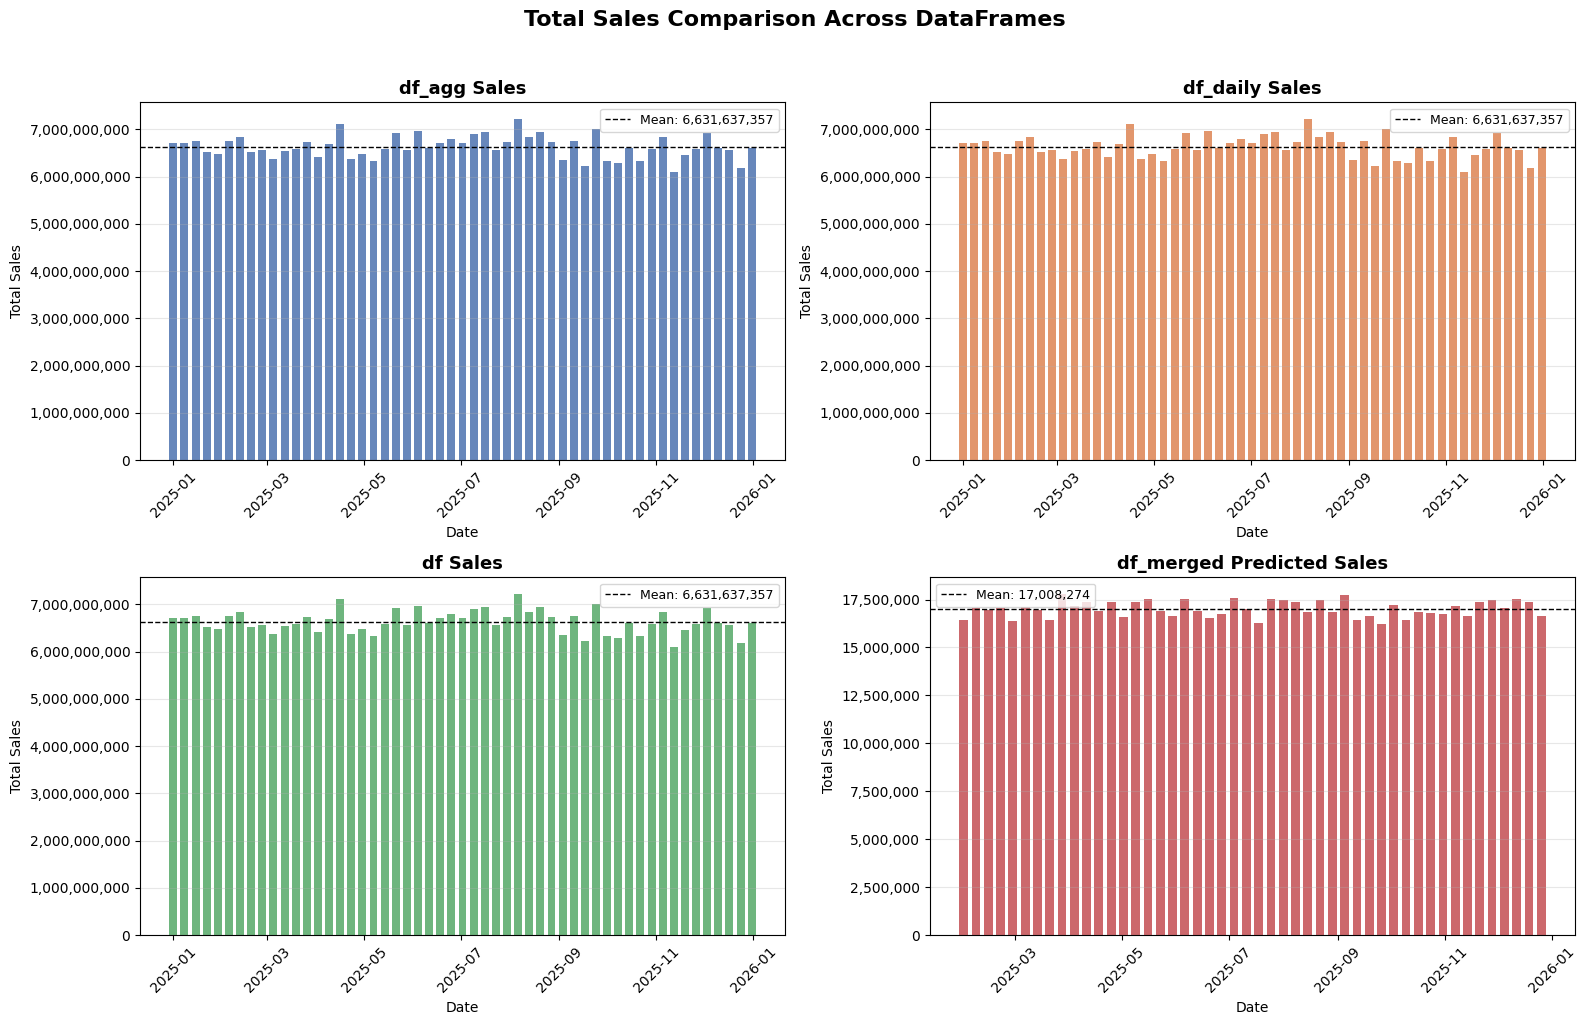

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Aggregate all sources by date
agg_sales       = df_agg.groupby('date')['sales'].sum().reset_index()
daily_sales     = df_daily.groupby('date')['sales'].sum().reset_index()
df_sales        = df.groupby('date')['sales'].sum().reset_index()
merged_sales    = df_merged.groupby('date')['predicted_sales'].sum().reset_index()

# Sample every 7 days to keep bars readable
agg_sales       = agg_sales.iloc[::7]
daily_sales     = daily_sales.iloc[::7]
df_sales        = df_sales.iloc[::7]
merged_sales    = merged_sales.iloc[::7]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
fig.suptitle('Total Sales Comparison Across DataFrames', fontsize=16, fontweight='bold', y=1.02)

plots = [
    (axes[0, 0], agg_sales,    'date', 'sales',           '#4C72B0', 'df_agg Sales'),
    (axes[0, 1], daily_sales,  'date', 'sales',           '#DD8452', 'df_daily Sales'),
    (axes[1, 0], df_sales,     'date', 'sales',           '#55A868', 'df Sales'),
    (axes[1, 1], merged_sales, 'date', 'predicted_sales', '#C44E52', 'df_merged Predicted Sales'),
]

for ax, data, x_col, y_col, color, title in plots:
    ax.bar(data[x_col], data[y_col], color=color, alpha=0.85, width=5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Total Sales', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x', rotation=45)
    # Add mean line
    mean_val = data[y_col].mean()
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1, label=f'Mean: {mean_val:,.0f}')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

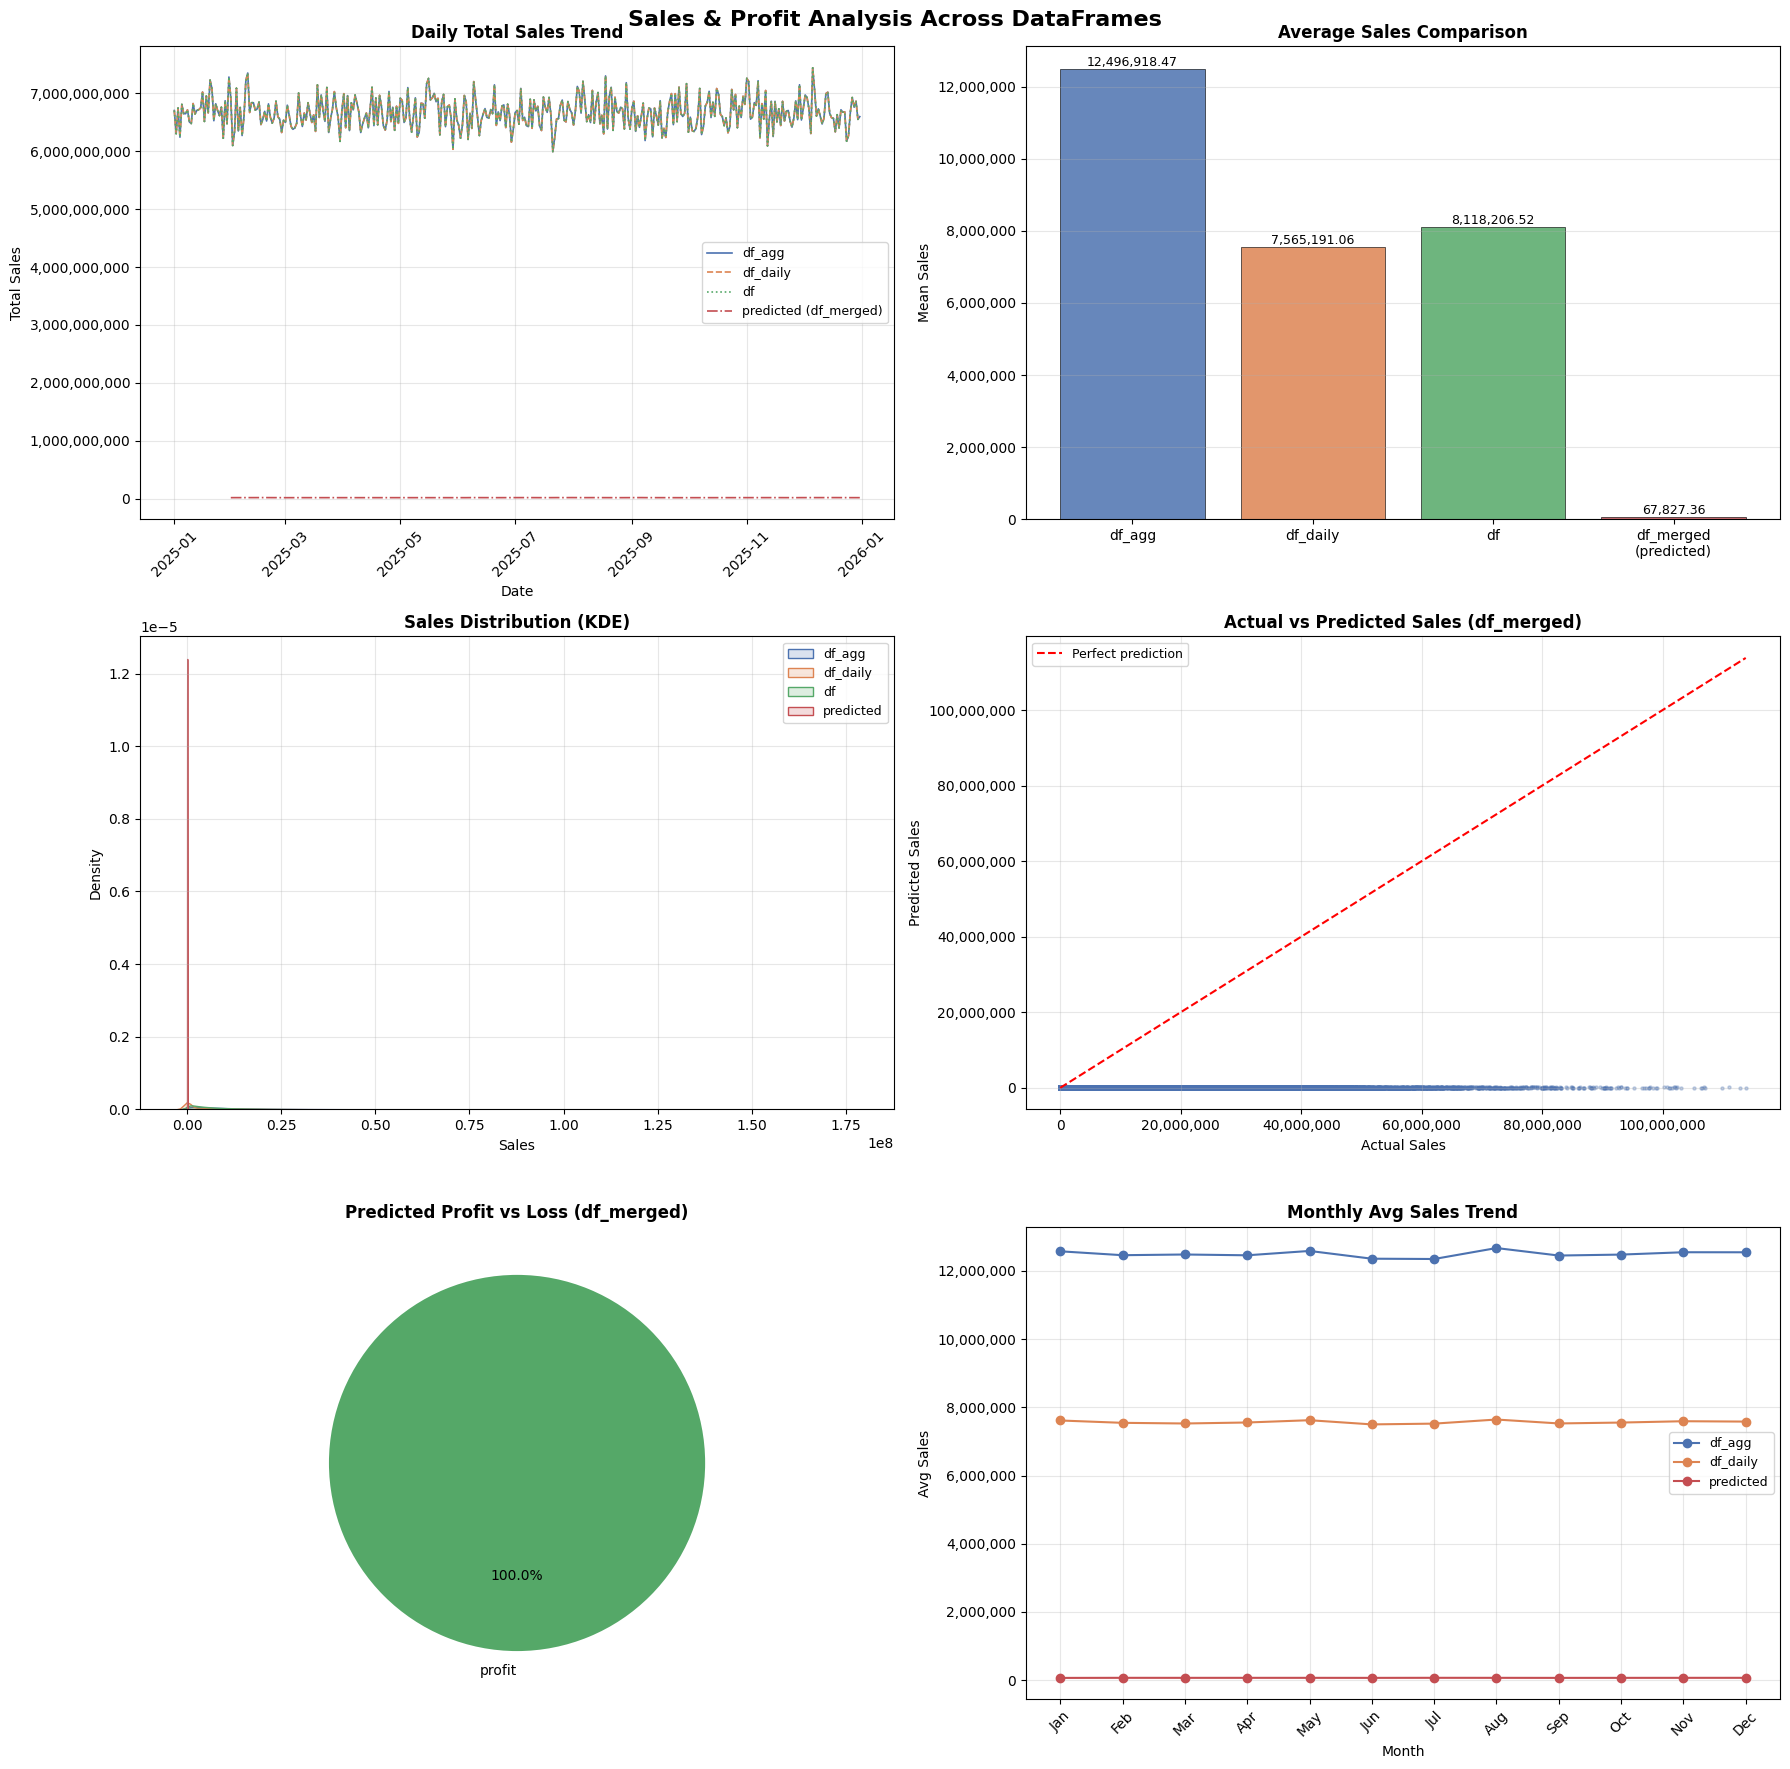

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Sales & Profit Analysis Across DataFrames', fontsize=16, fontweight='bold')

# ── 1. Daily Sales Trend ─────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(df_agg.groupby('date')['sales'].sum().reset_index()['date'],
        df_agg.groupby('date')['sales'].sum().reset_index()['sales'],
        label='df_agg', color='#4C72B0', linewidth=1.2)
ax.plot(df_daily.groupby('date')['sales'].sum().reset_index()['date'],
        df_daily.groupby('date')['sales'].sum().reset_index()['sales'],
        label='df_daily', color='#DD8452', linewidth=1.2, linestyle='--')
ax.plot(df.groupby('date')['sales'].sum().reset_index()['date'],
        df.groupby('date')['sales'].sum().reset_index()['sales'],
        label='df', color='#55A868', linewidth=1.2, linestyle=':')
ax.plot(df_merged.groupby('date')['predicted_sales'].sum().reset_index()['date'],
        df_merged.groupby('date')['predicted_sales'].sum().reset_index()['predicted_sales'],
        label='predicted (df_merged)', color='#C44E52', linewidth=1.2, linestyle='-.')
ax.set_title('Daily Total Sales Trend', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Total Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── 2. Bar: Avg Sales per DataFrame ──────────────────────────────────────────
ax = axes[0, 1]
labels = ['df_agg', 'df_daily', 'df', 'df_merged\n(predicted)']
means  = [
    df_agg['sales'].mean(),
    df_daily['sales'].mean(),
    df['sales'].mean(),
    df_merged['predicted_sales'].mean()
]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(labels, means, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:,.2f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Average Sales Comparison', fontweight='bold')
ax.set_ylabel('Mean Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)

# ── 3. Sales Distribution (KDE) ──────────────────────────────────────────────
ax = axes[1, 0]
sns.kdeplot(df_agg['sales'],   ax=ax, label='df_agg',   color='#4C72B0', fill=True, alpha=0.2)
sns.kdeplot(df_daily['sales'], ax=ax, label='df_daily',  color='#DD8452', fill=True, alpha=0.2)
sns.kdeplot(df['sales'],       ax=ax, label='df',        color='#55A868', fill=True, alpha=0.2)
sns.kdeplot(df_merged['predicted_sales'], ax=ax, label='predicted', color='#C44E52', fill=True, alpha=0.2)
ax.set_title('Sales Distribution (KDE)', fontweight='bold')
ax.set_xlabel('Sales'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── 4. Actual vs Predicted Sales Scatter ─────────────────────────────────────
ax = axes[1, 1]
ax.scatter(df_merged['sales'], df_merged['predicted_sales'],
           alpha=0.3, s=5, color='#4C72B0')
max_val = max(df_merged['sales'].max(), df_merged['predicted_sales'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title('Actual vs Predicted Sales (df_merged)', fontweight='bold')
ax.set_xlabel('Actual Sales'); ax.set_ylabel('Predicted Sales')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── 5. Profit Status Distribution ────────────────────────────────────────────
ax = axes[2, 0]
profit_counts = df_merged['predicted_profit'].value_counts()
wedge_colors  = ['#55A868', '#C44E52']
ax.pie(profit_counts, labels=profit_counts.index, autopct='%1.1f%%',
       colors=wedge_colors, startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Predicted Profit vs Loss (df_merged)', fontweight='bold')

# ── 6. Monthly Avg Sales ──────────────────────────────────────────────────────
ax = axes[2, 1]
def monthly_avg(data, col):
    tmp = data.copy()
    tmp['month'] = pd.to_datetime(tmp['date']).dt.month
    return tmp.groupby('month')[col].mean().reset_index()

for data, col, label, color in [
    (df_agg,    'sales',           'df_agg',    '#4C72B0'),
    (df_daily,  'sales',           'df_daily',  '#DD8452'),
    (df_merged, 'predicted_sales', 'predicted', '#C44E52'),
]:
    m = monthly_avg(data, col)
    ax.plot(m['month'], m[col], marker='o', label=label, color=color, linewidth=1.5)

ax.set_title('Monthly Avg Sales Trend', fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Avg Sales')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()